____

# Accessibility Audit of MTR Stations
___

# About the project

This project develops an Accessibility Index to evaluate how well MTR stations serve elderly and disabled populations across Hong Kong. By analyzing the availability of barrier-free facilities against demographic needs on district level, the index aims to:

- Identifies priority stations requiring urgent accessibility upgrades
- Highlights facility gaps
- Guides equitable urban planning to align infrastructure with community needs

**Data overview**

All data sourced from [Hong Kong Open Data](https://data.gov.hk/).

| Category | Source | Dataset |
|----------|--------|---------------|
|MTR barrier-free facilities| [CSV](https://data.gov.hk/en-data/dataset/mtr-data-routes-fares-barrier-free-facilities) | (1) Free-barrier facilities available at each MTR station; (2) Barrier-free facility details; (3) MTR station details |
|2021 Population census data| [API](https://data.gov.hk/en-data/dataset/hk-censtatd-census_geo-2021-population-census-by-dcd/resource/dd44d37e-85c7-49b7-b485-644db561cf80) | Hong Kong population by age group and district |
|GeoCommunity database | [CSV](https://data.gov.hk/en-data/dataset/hk-landsd-openmap-development-hkms-digital-geocom) | MTR station location |

**Index methodology**

1. Facility availability scoring: Weighted points for each facilities based on criticality
2. Area need adjustment scoring: Adjusted points based on facility availability score and %elderly population

# 1. Import required packages

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
import json
from pyproj import Transformer
import geopandas as gpd

# 2. Data cleaning & transformation

## 2.1. MTR barrier-free facilities

- `barrier_free_facility` contains records of accessibility features (elevators, ramps, etc.) available at each station
- `barrier_free_facility_category` provides standardized classifications for accessibility facilities
- `barrier_free_facility_scorecard` is a custom-developed dataset assigning weighted scores to each facility type based on its importance for elderly passengers (e.g., elevators = 3 points).
- `mtr_lines_and_stations` contains information on MTR stations and their code, enhancing the comprehensibility of the `barrier_free_facility` dataset

*All datasets except the scorecard originate from Hong Kong open data portal.*

In [32]:
barrier_free_facility = pd.read_csv('data/raw/barrier_free_facilities.csv')
barrier_free_facility_category = pd.read_csv('data/raw/barrier_free_facility_category.csv')
barrier_free_facility_scorecard = pd.read_csv('data/raw/barrier_free_facility_scorecard.csv')
mtr_lines_and_stations = pd.read_csv('data/raw/mtr_lines_and_stations.csv')

In [33]:
# Barrier-free facilities

# Drop unnecessary columns
barrier_free_facility.drop(columns=['Exit_Coordinate_X_Y', 'AJTextEn', 'AJTextZh'], inplace = True)

# Rename columns
barrier_free_facility = barrier_free_facility.rename(columns={'Key': 'barrier_free_facility_id',
                                                              'Value' : 'is_available'})

In [34]:
# Rename Item_Code to Facility_Id for consistency
barrier_free_facility_category.rename(columns={'Item_Code': 'Facility_Id'}, inplace=True)

barrier_free_facility_scorecard.rename(columns={'Item_Code': 'Facility_Id'}, inplace=True)

In [35]:
# MTR Lines and Stations
mtr_lines_and_stations.dropna(axis=0, how='all', inplace=True)

# Extract data on MTR station only, leaving out information on Line
mtr_stations = mtr_lines_and_stations[['Station ID', 'Station Code', 'English Name']].drop_duplicates(keep='first')

In [36]:
# Merge all 4 dataframes to get a comprehensive view of barrier-free facilities
barrier_free_facility_details = barrier_free_facility \
    .merge(barrier_free_facility_category, how='left', left_on='barrier_free_facility_id', right_on='Facility_Id') \
    .merge(mtr_stations, how='left', left_on='Station_No', right_on='Station ID') \
    .merge(barrier_free_facility_scorecard, how='left', left_on='barrier_free_facility_id', right_on='Facility_Id')
    
# Drop unnecessary columns
barrier_free_facility_details.drop(columns=['Facility_Id_x', 'Facility_Id_y', 'Category_Zh', 'Facility_Zh', 'Sorting_Order', 'Station ID',
                                            'Facility_En_x', 'Facility_En_y'],
                                   inplace=True)

# Rename columns
barrier_free_facility_details.rename(columns={'barrier_free_facility_id': 'facility_id',
                                              'Station_No': 'station_no',
                                              'Category_Id': 'facility_category_id',
                                              'Category_En': 'facility_category_en',
                                              'Facility_En': 'facility_en',
                                              'Station Code': 'station_code',
                                              'English Name': 'station_name_en',
                                              'Tier': 'tier',
                                              'Points': 'point',
                                              'Rationale': 'rationale'}, 
                                     inplace=True)

# Drop rows with NA station
barrier_free_facility_details.dropna(subset=['station_name_en', 'station_code'], inplace=True)

# Convert yes/no values to boolean
barrier_free_facility_details['is_available'].replace({'Y': True, 'N': False}, inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1476\81492361.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  barrier_free_facility_details['is_available'].replace({'Y': True, 'N': False}, inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1476\81492361.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcast

## 2.2. Population by age and district

### Import data from Census API

In [37]:
try:
    # Read data from Census API
    census_url = "https://idds.census2021.gov.hk/api/query?cv.AGE=0-4,5-9,10-14,15-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-10000&cv.AREA=11,12,13,14,27,23,24,25,26,31,32,33,34,35,36,37,38,39&sv.RP=RP_NPER&period=2021&lang=en"

    response = requests.get(census_url)
    census_data = response.json()

    # Save the json data to a file
    with open('data/raw/census_data.json', 'w') as f:
        json.dump(census_data, f)
except:
    # If the API call fails, read the data from a local file
    with open('data/raw/census_data.json', 'r') as f:
        census_data = json.load(f)

### Transformation: Convert JSON data to Dataframe

In [38]:
census_df = pd.json_normalize(census_data['dataSet'])
census_df['id'] = range(1, len(census_df) + 1)
census_df

,year,svCode,svDesc,spCode,spDesc,ccList,unit,figure,id
0,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '11', 'ccDesc': 'Central and Weste...",Persons,7583,1
1,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '11', 'ccDesc': 'Central and Weste...",Persons,8192,2
2,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '11', 'ccDesc': 'Central and Weste...",Persons,6989,3
3,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '11', 'ccDesc': 'Central and Weste...",Persons,9790,4
4,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '11', 'ccDesc': 'Central and Weste...",Persons,15723,5
...,...,...,...,...,...,...,...,...,...
319,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '39', 'ccDesc': 'Islands', 'cvCode...",Persons,10149,320
320,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '39', 'ccDesc': 'Islands', 'cvCode...",Persons,7376,321
321,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '39', 'ccDesc': 'Islands', 'cvCode...",Persons,3652,322
322,2021,RP,Population,RP_NPER,Number of Persons,"[{'ccCode': '39', 'ccDesc': 'Islands', 'cvCode...",Persons,2646,323


In [39]:
# Unnest ccList column

# Explode the list into separate rows
explored_ccList = census_df.explode('ccList')

# Expand dictionaries into columns
final_ccList = pd.concat(
    [explored_ccList.drop('ccList', axis=1), explored_ccList['ccList'].apply(pd.Series)],
    axis=1
)

final_ccList.drop(columns=['ccCode', 'cvCode', 'cvDesc'], inplace=True)
final_ccList

,year,svCode,svDesc,spCode,spDesc,unit,figure,id,ccDesc
0,2021,RP,Population,RP_NPER,Number of Persons,Persons,7583,1,Central and Western
0,2021,RP,Population,RP_NPER,Number of Persons,Persons,7583,1,0 - 4
1,2021,RP,Population,RP_NPER,Number of Persons,Persons,8192,2,Central and Western
1,2021,RP,Population,RP_NPER,Number of Persons,Persons,8192,2,10 - 14
2,2021,RP,Population,RP_NPER,Number of Persons,Persons,6989,3,Central and Western
...,...,...,...,...,...,...,...,...,...
321,2021,RP,Population,RP_NPER,Number of Persons,Persons,3652,322,75 - 79
322,2021,RP,Population,RP_NPER,Number of Persons,Persons,2646,323,Islands
322,2021,RP,Population,RP_NPER,Number of Persons,Persons,2646,323,80 - 84
323,2021,RP,Population,RP_NPER,Number of Persons,Persons,3473,324,Islands


In [40]:
#Split the ccList into two separate dataframes
# One for area and one for age
final_ccList_area = final_ccList.iloc[range(0, len(final_ccList), 2)]
final_ccList_age = final_ccList.iloc[range(1, len(final_ccList), 2)]

# Merge the two dataframes back into the original census_df
census_df = census_df.merge(final_ccList_area, how='left', on='id') \
    .merge(final_ccList_age, how='left', on='id')

In [41]:
# Drop unnecessary columns
population_area_age = census_df[['ccDesc_y', 'ccDesc_x', 'figure']]
population_area_age.rename(columns={'ccDesc_x': 'area', 
                          'ccDesc_y': 'age_group', 
                          'figure': 'population'}, inplace=True)

population_area_age

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1476\2772152117.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_area_age.rename(columns={'ccDesc_x': 'area',


,age_group,area,population
0,0 - 4,Central and Western,7583
1,10 - 14,Central and Western,8192
2,15 - 19,Central and Western,6989
3,20 - 24,Central and Western,9790
4,25 - 29,Central and Western,15723
...,...,...,...
319,65 - 69,Islands,10149
320,70 - 74,Islands,7376
321,75 - 79,Islands,3652
322,80 - 84,Islands,2646


### Transformation: Population by area and age group

In [42]:
# Total population by area
population_area_age['population'] = population_area_age['population'].astype(int)
population_by_area = population_area_age.groupby('area')['population'].sum().reset_index()

population_by_area

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1476\4292847676.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_area_age['population'] = population_area_age['population'].astype(int)


,area,population
0,Central and Western,235953
1,Eastern,529603
2,Islands,185282
3,Kowloon City,410634
4,Kwai Tsing,495798
5,Kwun Tong,673166
6,North,309631
7,Sai Kung,489037
8,Sha Tin,692806
9,Sham Shui Po,431090


In [43]:
# Calculate population percentage for each age group and district (area)
population_area_age = population_area_age.merge(population_by_area, how='left', on='area', suffixes=('', '_total'))
population_area_age['population_percentage'] = population_area_age['population'] / population_area_age['population_total'] * 100

population_area_age

,age_group,area,population,population_total,population_percentage
0,0 - 4,Central and Western,7583,235953,3.213776
1,10 - 14,Central and Western,8192,235953,3.471878
2,15 - 19,Central and Western,6989,235953,2.962031
3,20 - 24,Central and Western,9790,235953,4.149131
4,25 - 29,Central and Western,15723,235953,6.663615
...,...,...,...,...,...
319,65 - 69,Islands,10149,185282,5.477596
320,70 - 74,Islands,7376,185282,3.980959
321,75 - 79,Islands,3652,185282,1.971050
322,80 - 84,Islands,2646,185282,1.428093


### Transformation: Old population by area

In [44]:
# Create a tag to identify age groups belonging to elderly population
old_age_group = ['65 - 69', '70 - 74', '75 - 79', '80 - 84', '85+']
population_area_age['is_old'] = population_area_age['age_group'].apply(lambda x: 1 if x in old_age_group else 0)

# Calculate the percentage of elderly population in each area
old_population_by_area = population_area_age[population_area_age['is_old']==True] \
    .groupby('area')['population_percentage'].sum().reset_index()
old_population_by_area.rename(columns={'population_percentage': 'old_population_percentage'}, inplace=True)

old_population_by_area

,area,old_population_percentage
0,Central and Western,19.279687
1,Eastern,23.358440
2,Islands,14.732138
3,Kowloon City,20.080656
4,Kwai Tsing,22.078750
5,Kwun Tong,21.947187
6,North,17.942971
7,Sai Kung,15.801054
8,Sha Tin,19.989001
9,Sham Shui Po,20.398293


## 2.3. MTR station location

In [45]:
geo_comm = pd.read_csv('data/raw/GeoCom4.0_202503.csv')
geo_comm.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_1476\3558920495.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  geo_comm = pd.read_csv('data/raw/GeoCom4.0_202503.csv')


,GEONAMEID,ENGLISHNAME,CHINESENAME,CLASS,TYPE,SUBCAT,EASTING,NORTHING,SOURCE,E_FLOOR,...,E_DISTRICT,C_DISTRICT,E_REGION,C_REGION,E_ADDRESS,C_ADDRESS,TEL_NO,FAX_NO,WEB_SITE,REV_DATE
0,21243310,CANADIAN INTERNATIONAL SCHOOL,加拿大國際學校,SCH,KDG,KDGCCC,835302.0,812017.0,1,G/F,...,Southern District,南區,HK,香港,"UNITS G21-G24, SITE C, NO. 11 HEUNG YIP ROAD, ...",香港黃竹坑香葉道11號THE SOUTHSIDE地下G21—24號舖,<Null>,<Null>,NaN,20/3/2025
1,21243324,HKCT Institute of Higher Education (Yuen Long ...,港專學院 (元朗教學中心),SCH,TEI,NaN,821301.0,833974.0,1,G/F,...,Yuen Long District,元朗區,NT,新界,"Shop No. 22, Ground Floor, Golden Plaza, 28 Sh...",新界元朗水車館街28號萬金中心地下22號鋪,<Null>,<Null>,NaN,20/3/2025
2,21243329,Hong Kong College of Technology (Kwun Tong Lea...,香港專業進修學校 (觀塘教學中心),SCH,TEI,NaN,841232.0,819122.0,1,8/F,...,Kwun Tong District,觀塘區,KLN,九龍,"Room 801 and 802, 8/F, Wong Tze Building, 71 H...",九龍觀塘開源道71號王子大廈8樓,<Null>,<Null>,NaN,20/3/2025
3,21243337,IBEL RUSY AND PURVIZ SHROFF CHARITABLE FOUNDAT...,匯成勞士施羅孚伉儷慈善基金幼稚園,SCH,KDG,KDGCCC,835381.0,818146.0,1,1/F,...,Yau Tsim Mong District,油尖旺區,KLN,九龍,"SHOPS 119-121, 1/F., VICTORIA MALL, 188 CANTON...",九龍尖沙咀廣東道188號港景滙商場1樓119—121號舖,<Null>,<Null>,NaN,20/3/2025
4,21243321,HKCT Institute of Higher Education (Kwun Tong ...,港專學院 (觀塘教學中心),SCH,TEI,NaN,841234.0,819121.0,1,8/F,...,Kwun Tong District,觀塘區,KLN,九龍,"Room 801 and 802, 8/F, Wong Tze Building, 71 H...",九龍觀塘開源道71號王子大廈8樓,<Null>,<Null>,NaN,20/3/2025


In [46]:
# Filter for MTR stations only
mtr_station = geo_comm[(geo_comm['CLASS'] == 'TRS') & (geo_comm['TYPE'] == 'MTA')][['E_SITENAME', 'E_DISTRICT', 'EASTING', 'NORTHING']]
mtr_station = mtr_station.drop_duplicates(subset = ['E_SITENAME', 'E_DISTRICT'], keep = 'first').dropna().reset_index()

In [47]:
# Clean the MTR station name and district name to match with the format from census data and barrier-free facility data
mtr_station['E_SITENAME'] = mtr_station['E_SITENAME'].str.replace(r'Mass Transit Railway | Station', '', regex=True).str.strip()
mtr_station['E_DISTRICT'] = mtr_station['E_DISTRICT'].str.replace('District', '') \
        .str.replace('&', 'and') \
        .str.strip()

mtr_station.rename(columns={'E_SITENAME': 'station_name_en', 
                            'E_DISTRICT': 'area', 
                            'EASTING': 'long', 
                            'NORTHING' : 'lat'}, inplace=True)

# Drop inaccurate rows
mtr_station = mtr_station[~((mtr_station['station_name_en'] == 'Choi Hung') & (mtr_station['area'] == 'Kwun Tong') |
              (mtr_station['station_name_en'] == 'Kowloon Tong') & (mtr_station['area'] == 'Sham Shui Po'))] \
    .reset_index()

In [48]:
# Convert long and lat from HK1980 to WGS84
# Define transformer: from HK1980 Grid (EPSG:2326) to WGS84 (EPSG:4326)
transformer = Transformer.from_crs("EPSG:2326", "EPSG:4326", always_xy=True)

mtr_station['long'], mtr_station['lat'] = transformer.transform(mtr_station['long'], mtr_station['lat'])

## 2.4. Merge MTR barrier-free facility detail and elderly population data using MTR station location

In [49]:
barrier_free_facility_details = barrier_free_facility_details \
    .merge(mtr_station, how='left', on='station_name_en') \
    .merge(old_population_by_area, how='left', on='area')

## 2.5. Facility availability score

In [50]:
# Calculate score for each facility based on availability and point
# If the facility is available, the score is equal to the point
# If the facility is not available, the score is 0

barrier_free_facility_details['facility_available_score'] = np.where(
    barrier_free_facility_details['is_available'],
    barrier_free_facility_details['point'],
    0
)

barrier_free_facility_details

,station_no,facility_id,is_available,facility_category_id,facility_category_en,station_code,station_name_en,point,rationale,level_0,index,area,long,lat,old_population_percentage,facility_available_score
0,117,AJ1,False,AJ,System Accessibility,LOP,Long Ping,3,Critical for wheelchair boarding,15,5633,Yuen Long,114.023498,22.447527,15.023051,0
1,117,AJ2,True,AJ,System Accessibility,LOP,Long Ping,3,Important accessibility feature,15,5633,Yuen Long,114.023498,22.447527,15.023051,3
2,117,AJ3,True,AJ,System Accessibility,LOP,Long Ping,5,Essential for elderly with limited mobility or...,15,5633,Yuen Long,114.023498,22.447527,15.023051,5
3,117,AJ4,False,AJ,System Accessibility,LOP,Long Ping,5,Essential for elderly with limited mobility or...,15,5633,Yuen Long,114.023498,22.447527,15.023051,0
4,117,AJ5,False,AJ,System Accessibility,LOP,Long Ping,5,Essential for elderly with limited mobility or...,15,5633,Yuen Long,114.023498,22.447527,15.023051,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3487,94,VJ4,True,VJ,Facilities for Visually Impaired,EXC,Exhibition Centre,2,Alerts visually impaired; niche usage,43,12026,Wan Chai,114.174584,22.281234,21.223792,2
3488,94,VJ5,True,VJ,Facilities for Visually Impaired,EXC,Exhibition Centre,1,Helps visually impaired locate facilities; lim...,43,12026,Wan Chai,114.174584,22.281234,21.223792,1
3489,94,VJ6,True,VJ,Facilities for Visually Impaired,EXC,Exhibition Centre,1,Helpful but not critical,43,12026,Wan Chai,114.174584,22.281234,21.223792,1
3490,94,VJ7,True,VJ,Facilities for Visually Impaired,EXC,Exhibition Centre,5,Emergency communication essential,43,12026,Wan Chai,114.174584,22.281234,21.223792,5


In [52]:
#Widen the dataframe to get a score for each MTR station
indices = ['station_no', 'station_code', 'station_name_en', 'area', 'long', 'lat', 'old_population_percentage']
station_score = barrier_free_facility_details.pivot_table(index = indices,
                                    columns = 'facility_category_en',
                                    values = 'facility_available_score',
                                    aggfunc = 'sum')
station_score = station_score.reset_index(names=indices)

station_score.rename(columns={'Facilities for Hearing Impaired' : 'hearing_impared_facility',
                              'Facilities for Mobility Impaired' : 'mobility_impared_facility',
                              'Facilities for Visually Impaired': 'visually_impaired_facility',
                              'System Accessibility': 'system_accessibility'}, inplace=True)

In [ ]:
# Calculate total facility score for each station
facility_col = ['hearing_impared_facility', 
                'mobility_impared_facility', 
                'visually_impaired_facility', 
                'system_accessibility']

# Define the max score for each facility
max_scores = {
    'hearing_impared_facility': 12,
    'visually_impaired_facility': 28,
    'mobility_impared_facility': 25,
    'system_accessibility': 39
}

station_score['total_facility_score'] = station_score[facility_col].sum(axis=1)
station_score['normal_facility_score'] = (station_score['total_facility_score']/sum(max_scores.values())) * 100

# Normalize the facility score to a scale of 0-100
for col in facility_col:
    col_name = 'normal_' + col
    station_score[col_name] = (station_score[col] / max_scores[col]) * 100

station_score

facility_category_en,station_no,station_code,station_name_en,area,long,lat,old_population_percentage,hearing_impared_facility,mobility_impared_facility,visually_impaired_facility,system_accessibility,total_facility_score,normal_facility_score,normal_hearing_impared_facility,normal_mobility_impared_facility,normal_visually_impaired_facility,normal_system_accessibility
0,1,CEN,Central,Central and Western,114.158749,22.281636,19.279687,8,15,23,10,56,53.846154,66.666667,60.0,82.142857,25.641026
1,2,ADM,Admiralty,Central and Western,114.166065,22.278942,19.279687,10,15,22,15,62,59.615385,83.333333,60.0,78.571429,38.461538
2,3,TST,Tsim Sha Tsui,Yau Tsim Mong,114.173033,22.297604,17.887828,8,15,27,15,65,62.500000,66.666667,60.0,96.428571,38.461538
3,4,JOR,Jordan,Yau Tsim Mong,114.171905,22.303783,17.887828,8,11,23,10,52,50.000000,66.666667,44.0,82.142857,25.641026
4,5,YMT,Yau Ma Tei,Yau Tsim Mong,114.170402,22.312847,17.887828,8,15,23,15,61,58.653846,66.666667,60.0,82.142857,38.461538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,116,YUL,Yuen Long,Yuen Long,114.035234,22.446223,15.023051,8,15,23,18,64,61.538462,66.666667,60.0,82.142857,46.153846
93,117,LOP,Long Ping,Yuen Long,114.023498,22.447527,15.023051,8,15,23,13,59,56.730769,66.666667,60.0,82.142857,33.333333
94,118,TIS,Tin Shui Wai,Yuen Long,114.004523,22.448095,15.023051,8,15,23,18,64,61.538462,66.666667,60.0,82.142857,46.153846
95,119,SIH,Siu Hong,Tuen Mun,113.978596,22.410983,19.325125,8,15,23,16,62,59.615385,66.666667,60.0,82.142857,41.025641


In [ ]:
#station_score.to_csv('data/processed/station_score.csv', index=False)

# 3. Data visualization

## 4.1. Accessibility Index

#### 4.1.1. Statistics on accessibility index

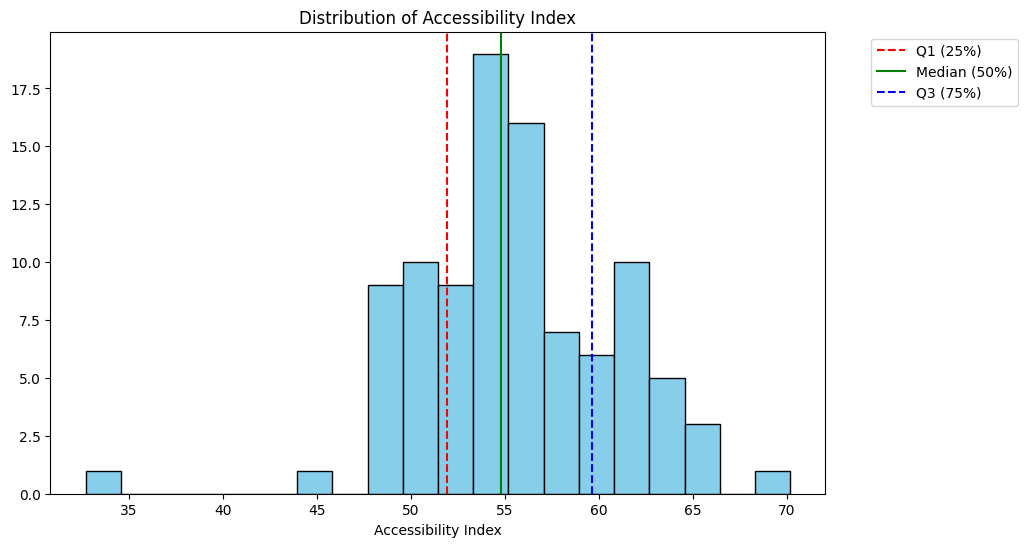

In [57]:
# Distribution of the accessibility index
plt.figure(figsize=(10,6))
plt.hist(station_score['normal_facility_score'], bins = 20, color='skyblue', edgecolor='black')

# Add vertical lines for quartiles
q1_index, q2_index, q3_index = station_score['normal_facility_score'].quantile([0.25, 0.5, 0.75])
plt.axvline(q1_index, color='red', linestyle='--', label='Q1 (25%)')
plt.axvline(q2_index, color='green', linestyle='-', label='Median (50%)')
plt.axvline(q3_index, color='blue', linestyle='--', label='Q3 (75%)')

plt.title('Distribution of Accessibility Index')
plt.xlabel('Accessibility Index')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('images/accessibility_index_distribution.png', dpi=300)
plt.show()

#### 4.1.2. Top and bottom stations in terms of accessibility index

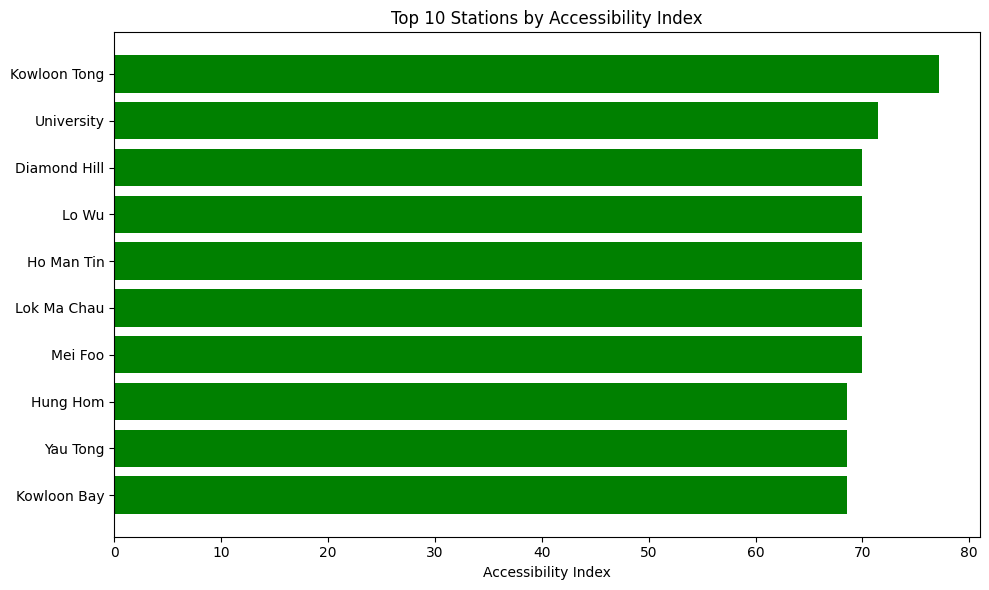

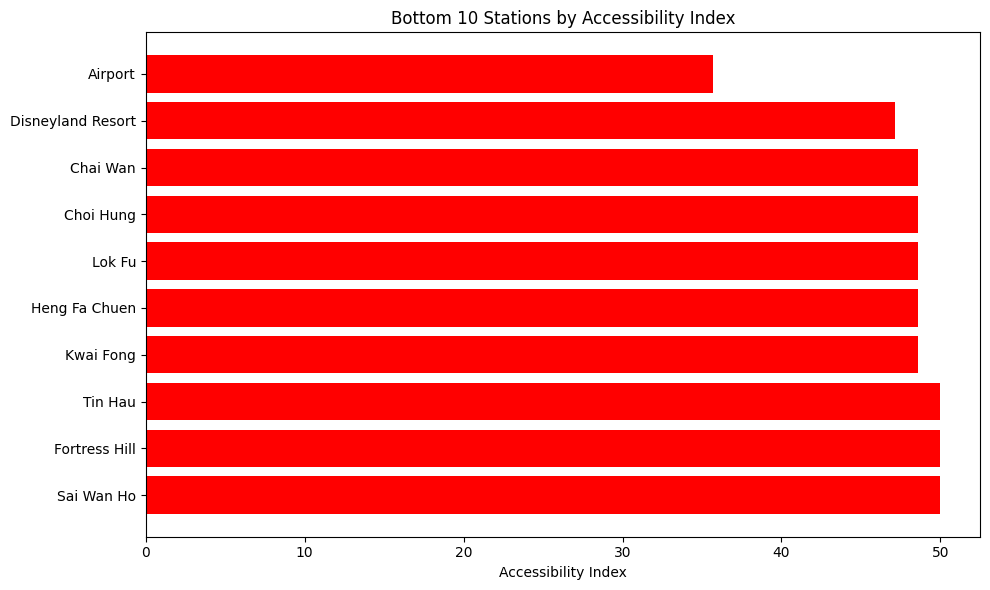

In [550]:
# Top 10 stations with highest accessibility index
top10 = station_score.nlargest(10, 'accessibility_index').sort_values('accessibility_index')

# Bottom 10 stations with lowest accessibility index
bottom10 = station_score.nsmallest(10, 'accessibility_index').sort_values('accessibility_index', ascending=False)

# ----- Top 10 Chart -----
plt.figure(figsize=(10, 6))
plt.barh(top10['station_name_en'], top10['accessibility_index'], color='green')
plt.title('Top 10 Stations by Accessibility Index')
plt.xlabel('Accessibility Index')
plt.tight_layout()
plt.savefig('images/top_10_accessibility.png', dpi=300)
plt.show()

# ----- Bottom 10 Chart -----
plt.figure(figsize=(10, 6))
plt.barh(bottom10['station_name_en'], bottom10['accessibility_index'], color='red')
plt.title('Bottom 10 Stations by Accessibility Index')
plt.xlabel('Accessibility Index')
plt.tight_layout()
plt.savefig('images/bottom_10_accessibility.png', dpi=300)
plt.show()


**Takeaway**
- Kowloon Tong, University, and Diamond Hill top the list, with the highest accessibility scores (near or above 50), suggesting these stations have strong infrastructure supporting inclusive access.
- On the other end, stations like Airport, Disneyland Resort, and Chai Wan rank lowest, with indices around 25–34, indicating significant room for improvement—even at major or high-traffic locations.
- The distribution reveals a noticeable disparity: no station scores above 55 or below 25, meaning most stations fall within a mid-range of accessibility, but even the best-performing stations are far from perfect.

#### 4.1.3. Percentage of accessibility category by district

- Categorize accessibility index into Low, Medium or High based on quartiles.
- Visualize the distribution of these index categories against district to identify districts that are in more urgent need to improve barrier-free facilities

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32384\2407142839.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  area_category_pct.sort_index().plot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32384\2407142839.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  area_category_pct.sort_index().plot(


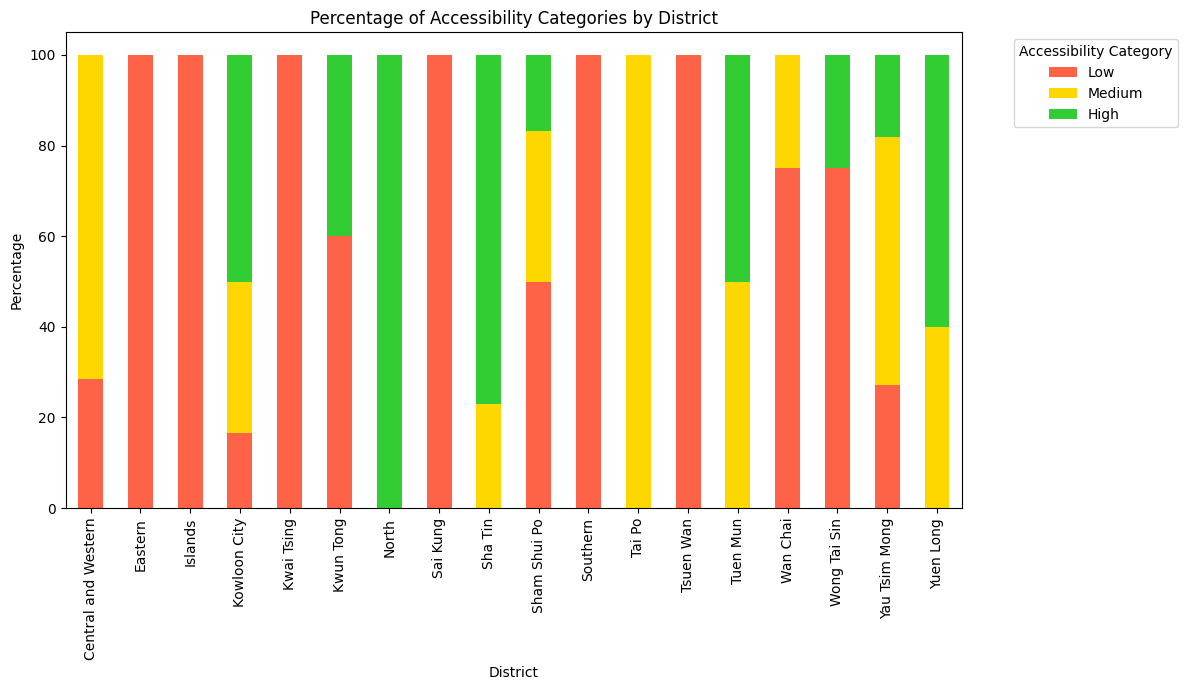

In [551]:
area_category_pct.sort_index().plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='Set2',
    color=['#FF6347', '#FFD700', '#32CD32']
)

plt.title('Percentage of Accessibility Categories by District')
plt.ylabel('Percentage')
plt.xlabel('District')
plt.legend(title='Accessibility Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/accessibility_by_district.png', dpi=300)
plt.show()

**Takeaways**
- Several districts, including Kwun Tong, North, Sha Tin, Tuen Mun, and Yuen Long, have 100% of their stations in the “Low” category, highlighting regions where accessibility is most lacking.
- In contrast, Central & Western and Wong Tai Sin are the only districts with any “High” accessibility stations, suggesting isolated examples of good design but no district-wide consistency.
- Most districts contain a mix of accessibility levels, which could indicate uneven investment in infrastructure or legacy systems that haven't been updated evenly.
- The absence of any district with majority “High” accessibility shows there is no clear accessibility leader in the network

#### 4.1.4. Prioritization of stations

Priority is set based on the following framework:

![](images/index_prioritization_framework.png)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32384\1434223152.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  area_priority_pct.sort_index().plot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32384\1434223152.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  area_priority_pct.sort_index().plot(


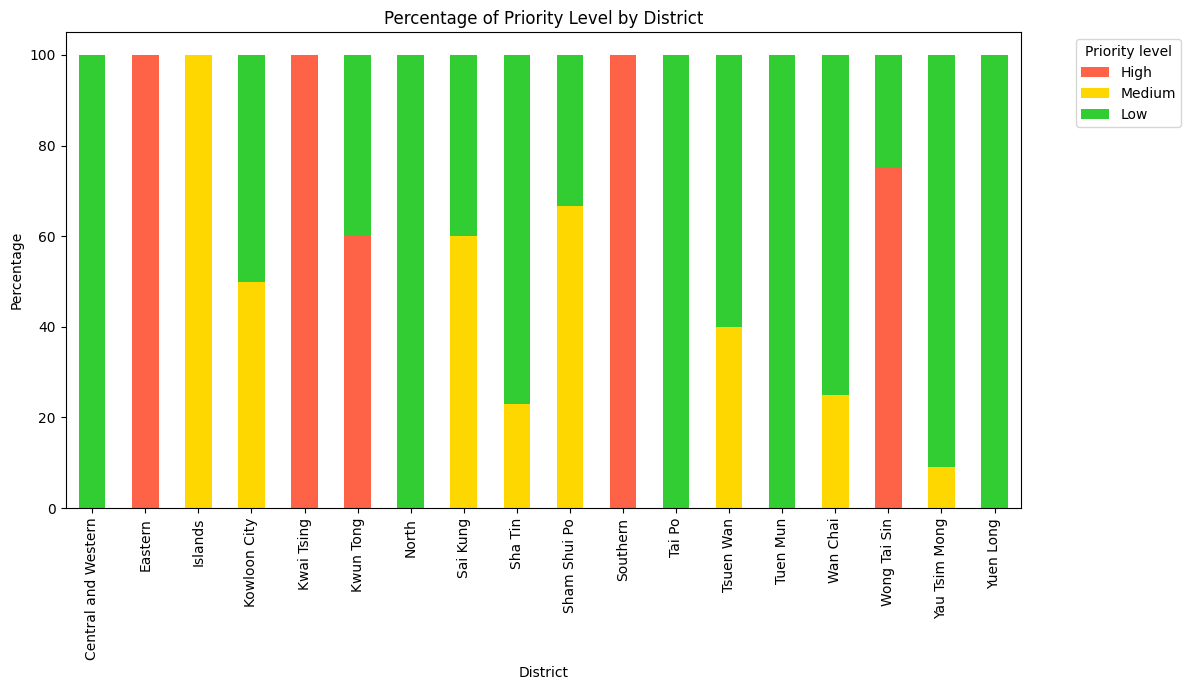

In [552]:
area_priority_pct.sort_index().plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='Set2',
    color=['#FF6347', '#FFD700', '#32CD32']
)

plt.title('Percentage of Priority Level by District')
plt.ylabel('Percentage')
plt.xlabel('District')
plt.legend(title='Priority level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/priority_by_district.png', dpi=300)
plt.show()

**Takeaways**
- This chart organizes districts by the urgency of accessibility improvements, based on how poorly stations perform and possibly how essential they are to local demographics.
- Districts such as Islands, Kwai Tsing, Southern, and Wong Tai Sin have a significant share of “High” priority stations, marking them as urgent targets for infrastructure upgrades.
- On the other hand, districts like North, Tai Po, Tuen Mun, and Yuen Long have all stations in the “Low” priority group, either because their accessibility needs are less severe or improvements are less urgent.
- Medium priority dominates many central and residential districts (e.g., Kowloon City, Sha Tin, Tsuen Wan), indicating these areas may benefit from phased or opportunistic improvements.

### 4.1.5. Accessibility index on a map

In [58]:
station_gdf = gpd.GeoDataFrame(
    station_score,
    geometry=gpd.points_from_xy(station_score['long'], station_score['lat']),
    crs="EPSG:4326"  # WGS84
)

district_gdf = gpd.read_file('data/raw/HKdistrict/HKdistrict18.shp')
district_gdf = district_gdf.to_crs("EPSG:4326")

In [59]:
# Drop columns
district_gdf.drop(columns=['CNAME', 'CNAME_S'], inplace=True)

# Rename
district_gdf.rename(columns={'ENAME': 'area'}, inplace=True)
district_gdf['area'] = district_gdf['area'].str.title()
district_gdf

,ID,area,geometry
0,1.0,Wong Tai Sin,"POLYGON ((114.17942 22.34905, 114.17946 22.349..."
1,6.0,Kowloon City,"MULTIPOLYGON (((114.177 22.34904, 114.17702 22..."
2,7.0,Kwun Tong,"POLYGON ((114.24371 22.2862, 114.2437 22.28613..."
3,8.0,Sai Kung,"MULTIPOLYGON (((114.22112 22.35318, 114.22114 ..."
4,11.0,North,"MULTIPOLYGON (((114.33576 22.51003, 114.33576 ..."
5,13.0,Central & Western,"MULTIPOLYGON (((114.14562 22.29045, 114.1499 2..."
6,14.0,Wan Chai,"MULTIPOLYGON (((114.20012 22.27387, 114.20047 ..."
7,15.0,Eastern,"POLYGON ((114.24738 22.25339, 114.24733 22.253..."
8,17.0,Tuen Mun,"MULTIPOLYGON (((113.93745 22.42638, 113.93765 ..."
9,18.0,Yuen Long,"MULTIPOLYGON (((113.93832 22.42696, 113.93843 ..."


KeyError: 'ENAME'

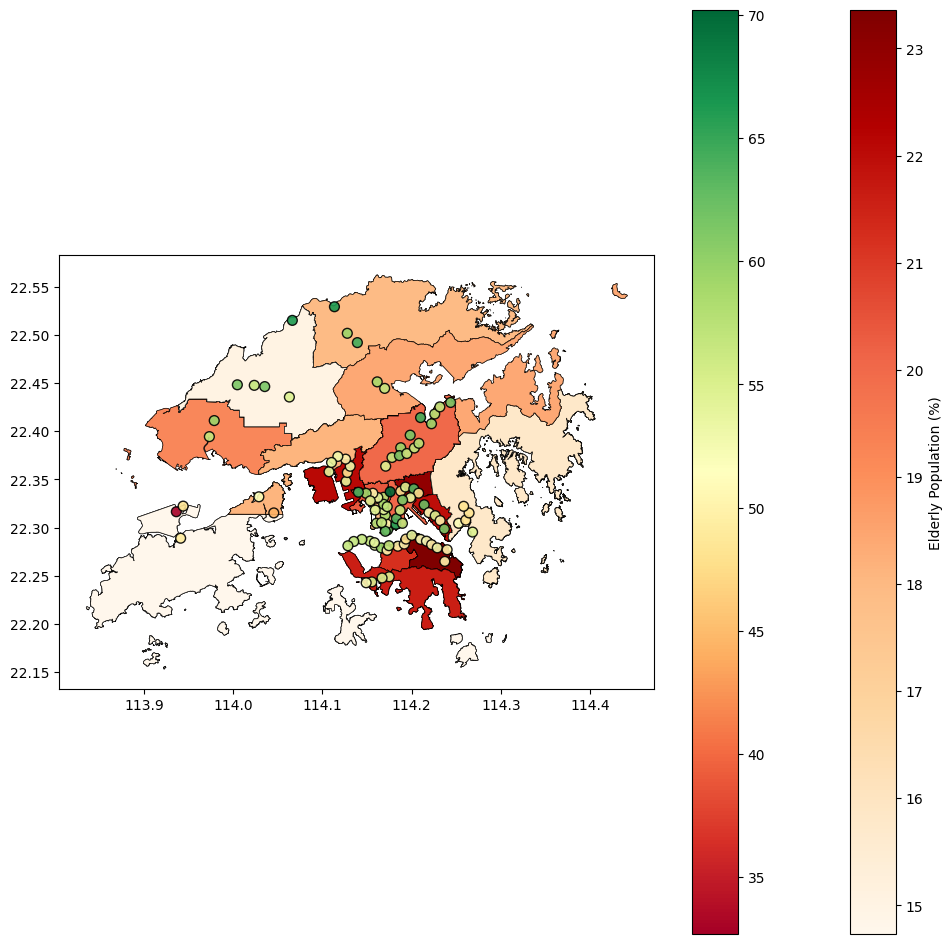

In [60]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot districts
district_gdf = district_gdf.merge(station_score[['area', 'old_population_percentage']], on ='area', how='left')

district_gdf.plot(
    ax=ax,
    column='old_population_percentage',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': "Elderly Population (%)"},
    alpha=0.8
)

# Plot stations
station_gdf.plot(
    ax=ax,
    column='normal_facility_score',
    cmap='RdYlGn',
    legend=True,
    markersize=50,
    alpha=0.9,
    edgecolor='black'
)

# Add district labels using centroid
for idx, row in district_gdf.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['ENAME'], 
            fontsize=9, ha='center', va='center')

plt.title("Hong Kong MTR Accessibility with Districts")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


## 4.2. Facility Score

### 4.2.1. Score comparison among facility type

In [ ]:
# Define the max score for each facility
max_scores = {
    'hearing_impared_facility': 10,
    'visually_impaired_facility': 21,
    'mobility_impared_facility': 17,
    'system_accessibility': 22
}

# Calculate total facility score and normalize using max scores
facility_df = station_score[facility_cols].sum().to_frame(name='total')
facility_df['max_possible'] = [max_scores[col] * len(station_score) for col in facility_cols]
facility_df['normalized_percent'] = (facility_df['total'] / facility_df['max_possible']) * 100


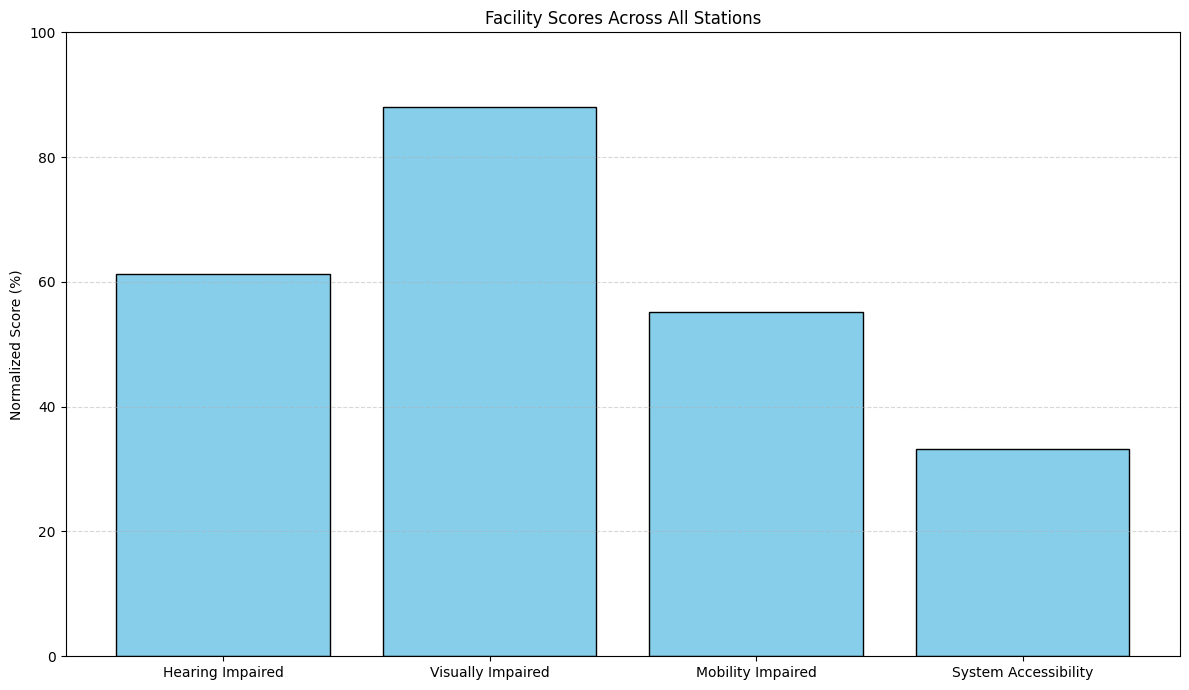

In [413]:
plt.figure(figsize=(12, 7))
plt.bar(
    facility_df.index,
    facility_df['normalized_percent'],
    color='skyblue',
    edgecolor='black'
)

x_labels = [
    'Hearing Impaired',
    'Visually Impaired',
    'Mobility Impaired',
    'System Accessibility'
]
plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=0)

plt.ylabel('Normalized Score (%)')
plt.title('Facility Scores Across All Stations')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('images/facility_score_overall.png', dpi=300)
plt.show()


**Takeaways**

- Despite having the highest number of items categorized as "Highly Important," the System Accessibility score ranks the lowest, highlighting a significant concern for the elderly and disabled populations. This indicates that the overall system's infrastructure remains largely inadequate in addressing the needs of passengers with mobility challenges.
- The category of "Mobility Impaired Facilities" follows closely behind with the second lowest score, further emphasizing the difficulties faced by elderly passengers in their daily commutes.

### 4.2.2. Facility score comparison among districts with high number of high-priority stations

In [414]:
selected_areas = ['Eastern', 'Kwai Tsing', 'Southern', 'Wong Tai Sin']
filtered_areas = station_score[station_score['area'].isin(selected_areas)].copy()

# Calculate total and max possible per district
grouped_total = filtered_areas.groupby('area')[facility_cols].sum()
station_counts = filtered_areas.groupby('area').size()

# Normalize scores
normalized_data = []
for col in facility_cols:
    max_possible = max_scores[col] * station_counts
    normalized = (grouped_total[col] / max_possible) * 100
    normalized_data.append(normalized)

filtered_areas = pd.DataFrame(normalized_data, index=facility_cols).T

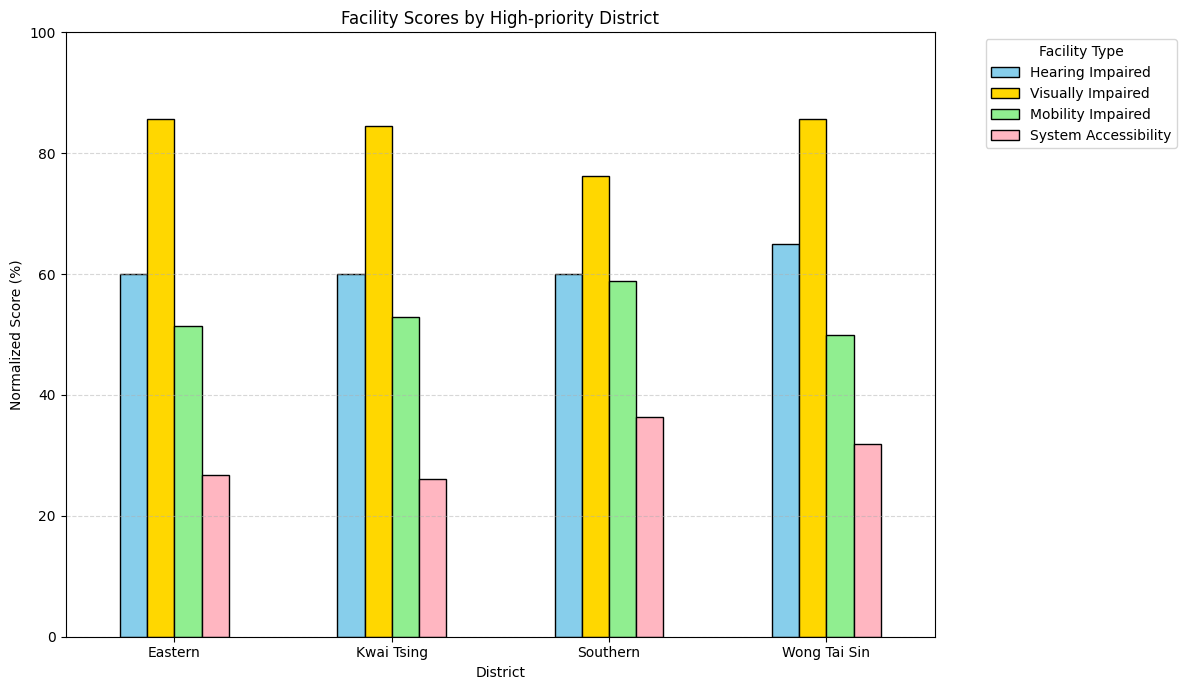

In [415]:
filtered_areas.plot(kind='bar', 
                    figsize=(12, 7),
                    color=['#87CEEB', '#FFD700', '#90EE90', '#FFB6C1'], 
                    edgecolor='black')

plt.xticks(rotation=0)
plt.xlabel('District')
plt.ylabel('Normalized Score (%)')
plt.title('Facility Scores by High-priority District')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Facility Type', labels=x_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/facility_score_selected.png', dpi=300)
plt.show()

**Takeaways**
- Similar to the overall trend, the four most challenged districts show significant shortcomings in System Accessibility facilities. This issue is particularly alarming in Kwai Tsing, where the elderly population percentage is one of the highest, yet the district's System Accessibility score is the lowest. 
